In [1]:
import os
import re
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import nibabel as nib
from scipy.spatial.distance import euclidean
from lameg.viz import rgbtoint
import k3d
import io
from PIL import Image
from base64 import b64decode

In [2]:
plt.rcParams.update({
    'font.size': 16,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'xtick.major.size': 6,
    'xtick.major.width': 1.2,
    'ytick.major.size': 6,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.handletextpad': 0.1,
    'svg.fonttype': 'none',
    'text.usetex': False
})

In [3]:
def add_subplot_label(ax, label, x=-.21, y=1.225, fontsize=26):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=fontsize, va='top', ha='right')


In [4]:
out_dir='../output/ori_simulations'
surf_dir='/home/common/bonaiuto/cued_action_meg/derivatives/processed/sub-001/surf/'
n_layers=11

In [5]:
vx_loc, vx_adj, surf_norm = nib.load(os.path.join(surf_dir, "multilayer.11.ds.link_vector.fixed.gii")).agg_data()
layers_loc = np.array(np.split(vx_loc, n_layers, axis=0))
verts_per_layer=int(vx_loc.shape[0]/n_layers)
faces_per_layer=int(vx_adj.shape[0]/n_layers)

In [6]:
# Define the simulation and reconstruction methods
methods = [
    "link_vector.fixed", 
    "orig_surf_norm.fixed", "orig_surf_norm.not_fixed",
    "cps.fixed", "cps.not_fixed", 
    "ds_surf_norm.fixed", "ds_surf_norm.not_fixed"
]

# Format method names for plotting (remove underscores)
formatted_methods = ['LV','OSNf','OSN','CPSf','CPS','DSNf','DSN']

method_norms={}
for method in methods:
    _, _, method_norms[method] = nib.load(os.path.join(surf_dir, f"multilayer.11.ds.{method}.gii")).agg_data()

In [7]:
plot = k3d.plot(
    grid_visible=False, menu_visibility=False, camera_auto_fit=False, camera_fov=20
)
cam_view=[22.704202588225176,
 27.1826958924778,
 70.78994483203148,
 22.201248358898624,
 27.15286322513241,
 70.69552718000556,
 -0.16579015573433048,
 -0.2356008912651561,
 0.9576042211146797]

method_colors=[
    [0,0,0],
    [117,112,179],
    [231,41,138],
    [230,171,2]
]
methods_to_plot=['link_vector.fixed', 'orig_surf_norm.not_fixed', 'cps.not_fixed', 'ds_surf_norm.not_fixed']

col_r = plt.cm.cool(np.linspace(0,1, num=n_layers))
for i in range(n_layers):
    layer_verts=vx_loc[i*verts_per_layer:(i+1)*verts_per_layer,:]
    layer_faces=vx_adj[:faces_per_layer,:]
    layer_mesh = k3d.mesh(layer_verts, layer_faces, side="double", color=rgbtoint(col_r[i,:3]*255), opacity=0.5)
    for m_idx, method in enumerate(methods_to_plot):
        layer_vectors = method_norms[method][i*verts_per_layer:(i+1)*verts_per_layer,:]
        dipole_vectors = k3d.vectors(
            layer_verts,
            color=rgbtoint(method_colors[m_idx]),
            head_color=rgbtoint(method_colors[m_idx]),
            origin_color=rgbtoint(method_colors[m_idx]),
            vectors=-1.1*layer_vectors,
            head_size=1,
            line_width=0.1
        )
        plot += dipole_vectors
    plot += layer_mesh
    

plot.camera=cam_view
plot.display()

Output()

In [8]:
plot.fetch_screenshot()

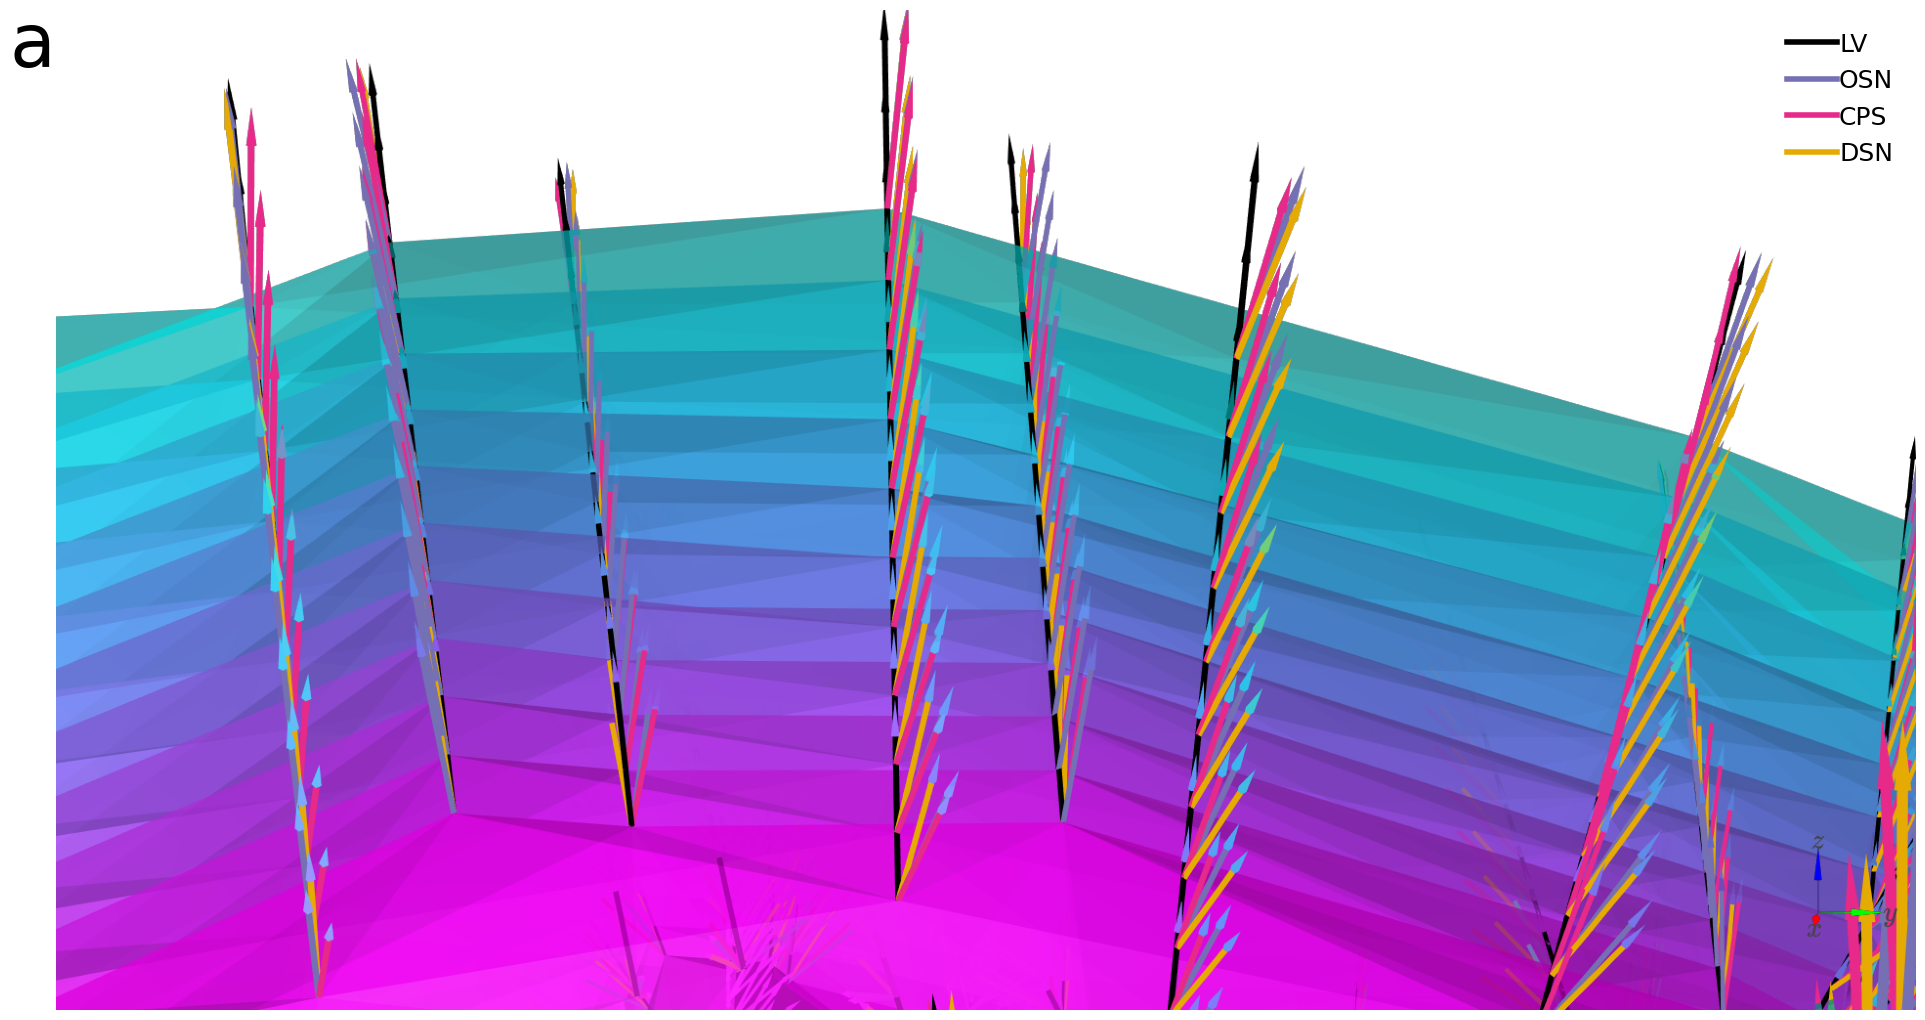

In [9]:
# Decode the screenshot
image_data = b64decode(plot.screenshot)
image = Image.open(io.BytesIO(image_data))
image_array = np.array(image)

# Set up figure and axis
fig, ax = plt.subplots(figsize=(24, 16))
ax.imshow(image_array)
ax.axis('off')  # Hide axes

legend_elements = [
    Line2D([0], [0], color=np.array(c) / 255, lw=4, label=method)
    for c, method in zip(method_colors, ['LV','OSN','CPS','DSN'])
]

ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=18,
    frameon=False
)

add_subplot_label(ax, 'a', fontsize=54, x=0, y=1)

# Show and save figure
plt.savefig(f"figure_06_orientation_vectors.pdf")

In [20]:
method_diff=np.zeros((n_layers,len(methods),len(methods)))
for m_idx1, method1 in enumerate(methods):
    norm1 = method_norms[method1]
    for m_idx2, method2 in enumerate(methods):
        norm2 = method_norms[method2]
        
        for l in range(n_layers):
            l_norm1=norm1[l*verts_per_layer:(l+1)*verts_per_layer]
            l_norm2=norm2[l*verts_per_layer:(l+1)*verts_per_layer]
            
            # Ensure the vectors are normalized
            norm1_normalized = l_norm1 / np.linalg.norm(l_norm1, axis=1, keepdims=True)
            norm2_normalized = l_norm2 / np.linalg.norm(l_norm2, axis=1, keepdims=True)

            # Compute the dot product between corresponding vectors
            dot_product = np.sum(norm1_normalized * norm2_normalized, axis=1)

            # Clip the dot product to avoid numerical errors outside the [-1, 1] range
            dot_product = np.clip(dot_product, -1.0, 1.0)

            # Compute the angular difference in degrees
            angles_degrees = np.degrees(np.arccos(dot_product))
            method_diff[l,m_idx1,m_idx2]=np.nanmedian(angles_degrees)

/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/site-packages/ipykernel_launcher.py:12: RuntimeWarning: invalid value encountered in true_divide
  if sys.path[0] == "":
/home/bonaiuto/miniconda3/envs/laminar_erf/lib/python3.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in true_divide
  del sys.path[0]


In [21]:
# Initialize a matrix to accumulate errors for all vertices

# List to store the unique vertex numbers
vertex_numbers = set()

# Iterate through all files in the directory to find the vertex numbers
for file_name in os.listdir(out_dir):
    # Match the pattern vx_<vertex_number>_sim_ with regular expression
    match = re.match(r"vx_(\d+)_sim_", file_name)
    if match:
        vertex_number = int(match.group(1))
        vertex_numbers.add(vertex_number)


error_matrix_all = np.zeros((len(vertex_numbers),7, 7))
layer_error_matrix_all = np.zeros((len(vertex_numbers),n_layers,7, 7))

# Iterate through all detected vertices
for v_idx, vertex_num in enumerate(vertex_numbers):
    for i, sim_method in enumerate(methods):
        for j, reco_method in enumerate(methods):
            # Construct the file name for the current vertex
            file_name = f"vx_{vertex_num}_sim_{sim_method}_reco_{reco_method}.pickle"
            file_path = os.path.join(out_dir, file_name)
            
            # Load the .pickle file
            with open(file_path, 'rb') as file:
                data = pickle.load(file)

            # Extract the layerF matrix
            layerF = data['layerF']

            # Calculate the observed peaks (row index of max value for each column)
            observed_peaks = np.argmax(layerF, axis=1)

            # Calculate the ideal peaks (diagonal)
            ideal_peaks = np.arange(layerF.shape[1])

            # Compute the errors (distance between observed and ideal peaks)
            errors = np.abs(observed_peaks - ideal_peaks)

            # Accumulate the errors
            error_matrix_all[v_idx, i, j] = np.mean(errors)
            layer_error_matrix_all[v_idx, :, i, j] = errors            

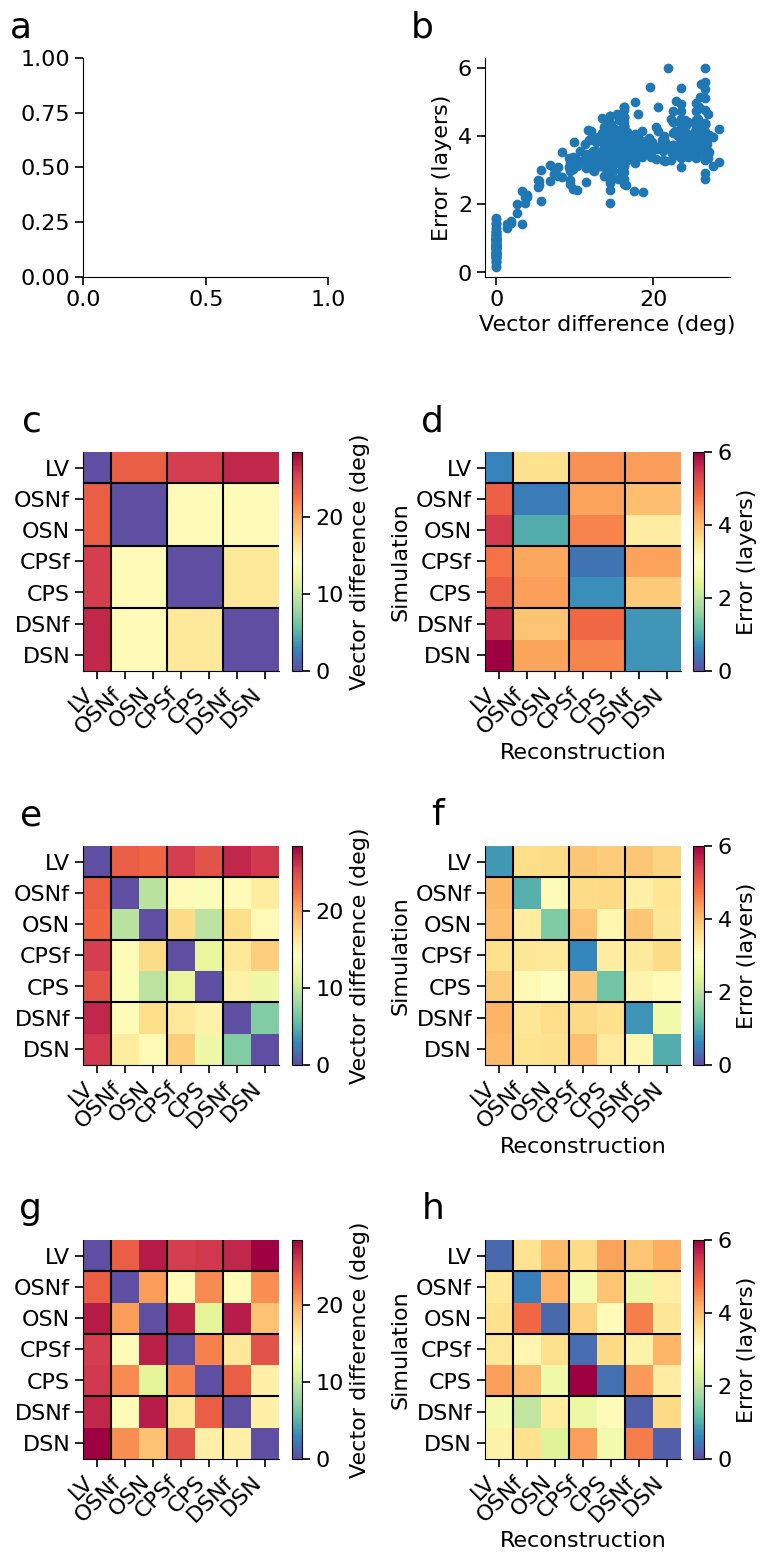

In [34]:
deg_lims=[0, np.max(method_diff[:])]

m_layer_error=np.mean(layer_error_matrix_all,axis=0)
err_lims=[0, np.max(m_layer_error)]

fig=plt.figure(figsize=(8, 16), facecolor="white")
gs = GridSpec(4, 2)

ax = fig.add_subplot(gs[0, 0])
add_subplot_label(ax, 'a', y=1.22)

ax = fig.add_subplot(gs[0, 1])
ax.scatter(method_diff[:],m_layer_error[:])
ax.set_xlabel('Vector difference (deg)')
ax.set_ylabel('Error (layers)')
add_subplot_label(ax, 'b', y=1.22)

labels=['c','d','e','f','g','h']
for l_idx, l in enumerate([0,5,-1]):
    ax = fig.add_subplot(gs[1+l_idx, 0])
    cax=ax.imshow(method_diff[l,:,:], cmap='Spectral_r', aspect='auto', interpolation='none', clim=deg_lims)
    ax.axhline(0.5,color='k')
    ax.axhline(2.5,color='k')
    ax.axhline(4.5,color='k')
    ax.axvline(0.5,color='k')
    ax.axvline(2.5,color='k')
    ax.axvline(4.5,color='k')
    # Add labels and titles
    ax.set_xticks(np.arange(len(methods)))
    ax.set_yticks(np.arange(len(methods)))
    ax.set_xticklabels(formatted_methods, rotation=45, ha="right")
    ax.set_yticklabels(formatted_methods)
    fig.colorbar(cax, label="Vector difference (deg)", ax=ax)
    add_subplot_label(ax, labels[l_idx*2], y=1.22)
    
    ax = fig.add_subplot(gs[1+l_idx, 1])
    cax=ax.imshow(m_layer_error[l,:,:], cmap='Spectral_r', aspect='auto', interpolation='none', clim=err_lims)
    ax.axhline(0.5,color='k')
    ax.axhline(2.5,color='k')
    ax.axhline(4.5,color='k')
    ax.axvline(0.5,color='k')
    ax.axvline(2.5,color='k')
    ax.axvline(4.5,color='k')
    # Add labels and titles
    ax.set_xticks(np.arange(len(methods)))
    ax.set_yticks(np.arange(len(methods)))
    ax.set_xticklabels(formatted_methods, rotation=45, ha="right")
    ax.set_yticklabels(formatted_methods)
    ax.set_xlabel("Reconstruction")
    ax.set_ylabel("Simulation")
    fig.colorbar(cax, label="Error (layers)", ax=ax)
    add_subplot_label(ax, labels[l_idx*2+1], y=1.22)
plt.tight_layout()
    
plt.savefig(f"figure_06_orientation.pdf")